In [116]:
import pandas as pd
import numpy as np

In [117]:
df = pd.read_csv('earthquake_alert_balanced_dataset.csv')
df.head()

,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green


In [118]:
df.shape

(1300, 6)

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1300 non-null   float64
 1   depth      1300 non-null   float64
 2   cdi        1300 non-null   float64
 3   mmi        1300 non-null   float64
 4   sig        1300 non-null   float64
 5   alert      1300 non-null   object 
dtypes: float64(5), object(1)
memory usage: 61.1+ KB


In [120]:
df.isnull().sum().sum()

np.int64(0)

In [121]:
duplicates_mask=df.duplicated()
duplicates_mask.sum()

np.int64(44)

In [122]:
df = df.drop_duplicates()


In [123]:
duplicates_mask=df.duplicated()
duplicates_mask.sum()

np.int64(0)

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1256 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1256 non-null   float64
 1   depth      1256 non-null   float64
 2   cdi        1256 non-null   float64
 3   mmi        1256 non-null   float64
 4   sig        1256 non-null   float64
 5   alert      1256 non-null   object 
dtypes: float64(5), object(1)
memory usage: 68.7+ KB


In [125]:
for i in df.columns:
    if(df[i].dtype == 'int64' and df[i].isna().sum()!=0):
        print(i , df[i].dtype , df[i].isna().sum())

In [126]:
for i in df.columns:
    if(df[i].dtype == 'float64' and df[i].isna().sum()!=0):
        print(i , df[i].dtype , df[i].isna().sum())

In [127]:
for i in df.columns:
    if(df[i].dtype == 'int64'):
        print(i , df[i].value_counts())

In [128]:
for i in df.columns:
    if(df[i].dtype == 'float64'):
        print(i , df[i].value_counts())

magnitude magnitude
6.50    98
6.60    77
6.90    70
6.70    53
6.80    48
        ..
8.17     1
8.09     1
7.87     1
8.02     1
8.33     1
Name: count, Length: 167, dtype: int64
depth depth
10.0     109
9.0       70
12.0      69
11.0      59
13.0      51
        ... 
595.0      1
414.0      1
169.0      1
553.0      1
129.0      1
Name: count, Length: 173, dtype: int64
cdi cdi
8.0    514
9.0    233
7.0    184
6.0    101
5.0     75
0.0     59
4.0     34
3.0     30
1.0     14
2.0     12
Name: count, dtype: int64
mmi mmi
8.0    443
7.0    426
6.0    164
5.0     67
4.0     64
9.0     53
3.0     34
2.0      4
1.0      1
Name: count, dtype: int64
sig sig
 93.0     23
-118.0    19
 26.0     18
-115.0    18
-98.0     18
          ..
 20.0      1
 6.0       1
-107.0     1
-83.0      1
 37.0      1
Name: count, Length: 238, dtype: int64


In [129]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [130]:
for i in df.columns: 
    if(df[i].dtype == 'object'): 
        df[i] = le.fit_transform(df[i])
        print(i , df[i].value_counts())

alert alert
0    322
3    318
1    316
2    300
Name: count, dtype: int64


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1256 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1256 non-null   float64
 1   depth      1256 non-null   float64
 2   cdi        1256 non-null   float64
 3   mmi        1256 non-null   float64
 4   sig        1256 non-null   float64
 5   alert      1256 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.7 KB


In [132]:
correlation=df.corr()
correlation

,magnitude,depth,cdi,mmi,sig,alert
magnitude,1.000000,-0.017037,0.326727,0.306400,0.239390,0.229520
depth,-0.017037,1.000000,-0.372096,-0.567678,-0.100912,-0.252869
cdi,0.326727,-0.372096,1.000000,0.676274,0.376892,0.446708
mmi,0.306400,-0.567678,0.676274,1.000000,0.325530,0.451719
sig,0.239390,-0.100912,0.376892,0.325530,1.000000,0.124579
alert,0.229520,-0.252869,0.446708,0.451719,0.124579,1.000000


In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

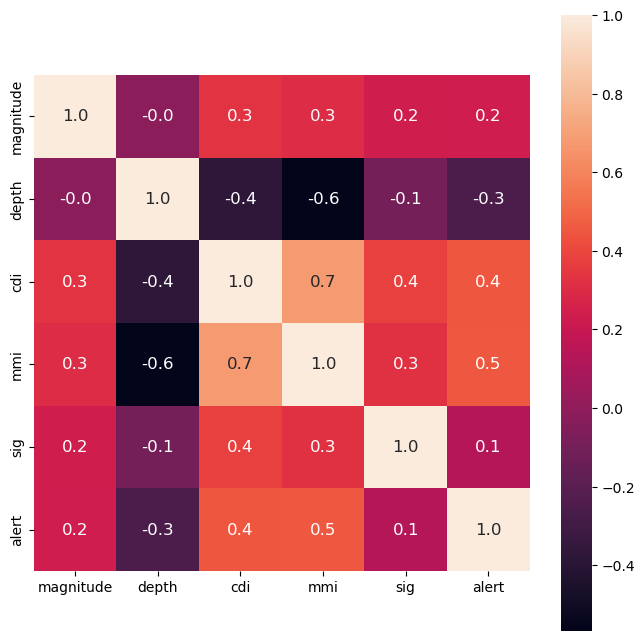

In [134]:
plt.figure(figsize=(8,8))
sns.heatmap(correlation,square=True,fmt='.1f',annot=True,annot_kws={'size':12})

Data Spliting

In [135]:
X=df.drop("alert", axis = 1)
Y = df["alert"]

In [136]:
X.info()
X.shape

<class 'pandas.core.frame.DataFrame'>
Index: 1256 entries, 0 to 1299
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1256 non-null   float64
 1   depth      1256 non-null   float64
 2   cdi        1256 non-null   float64
 3   mmi        1256 non-null   float64
 4   sig        1256 non-null   float64
dtypes: float64(5)
memory usage: 58.9 KB


(1256, 5)

In [137]:
Y.info()
Y.shape

<class 'pandas.core.series.Series'>
Index: 1256 entries, 0 to 1299
Series name: alert
Non-Null Count  Dtype
--------------  -----
1256 non-null   int64
dtypes: int64(1)
memory usage: 19.6 KB


(1256,)

In [138]:
from sklearn.model_selection import train_test_split
X_TRAIN , X_TEST , Y_TRAIN, Y_TEST = train_test_split(X,Y, test_size = 0.25, random_state=30)
print("Size of Train X = " , len(X_TRAIN))
print("Size of Train Y = " , len(Y_TRAIN))
print("Size of Test X = " , len(X_TEST))
print("Size of Test Y = " , len(Y_TEST))

Size of Train X =  942
Size of Train Y =  942
Size of Test X =  314
Size of Test Y =  314


In [139]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=7, random_state=15)

In [140]:
# train the classifier
rf_model.fit(X_TRAIN, Y_TRAIN)

RandomForestClassifier(n_estimators=7, random_state=15)

In [141]:
# accuracy for prediction on training data
training_data_prediction = rf_model.predict(X_TRAIN)
training_data_prediction

array([3, 1, 0, 0, 1, 2, 3, 3, 2, 2, 1, 2, 3, 0, 1, 2, 3, 1, 2, 1, 1, 1,
       1, 0, 0, 2, 0, 2, 0, 3, 3, 2, 3, 0, 2, 2, 0, 2, 3, 2, 0, 2, 2, 1,
       2, 2, 2, 0, 1, 3, 1, 1, 1, 3, 1, 0, 2, 0, 0, 3, 0, 1, 3, 1, 0, 2,
       1, 3, 2, 1, 3, 3, 0, 0, 3, 0, 0, 1, 2, 0, 1, 2, 1, 2, 2, 2, 2, 1,
       2, 0, 3, 2, 1, 3, 1, 0, 3, 0, 0, 1, 2, 2, 0, 2, 2, 3, 1, 1, 0, 2,
       0, 1, 1, 1, 0, 0, 2, 3, 1, 2, 3, 0, 3, 1, 1, 2, 2, 2, 2, 3, 2, 2,
       0, 0, 0, 3, 0, 0, 2, 1, 2, 3, 1, 0, 3, 3, 1, 3, 3, 3, 3, 0, 1, 2,
       0, 1, 0, 2, 0, 0, 1, 3, 1, 2, 3, 1, 1, 3, 1, 0, 3, 2, 3, 1, 3, 3,
       3, 0, 3, 3, 3, 0, 1, 0, 3, 0, 1, 2, 3, 2, 0, 2, 1, 3, 0, 1, 1, 1,
       3, 2, 1, 0, 1, 1, 2, 2, 2, 0, 3, 1, 3, 3, 3, 2, 3, 0, 1, 3, 0, 0,
       1, 1, 3, 2, 1, 0, 1, 0, 2, 3, 3, 3, 3, 2, 0, 3, 3, 3, 3, 0, 0, 0,
       3, 3, 2, 3, 1, 2, 0, 0, 2, 1, 3, 1, 2, 1, 3, 0, 3, 2, 3, 3, 1, 3,
       1, 2, 2, 0, 3, 2, 2, 1, 1, 0, 0, 0, 2, 2, 0, 1, 0, 2, 2, 0, 3, 2,
       2, 3, 0, 0, 3, 3, 1, 2, 1, 1, 0, 1, 0, 0, 0,

In [142]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_TRAIN, training_data_prediction)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.9872611464968153


In [143]:
from sklearn.metrics import classification_report, confusion_matrix
confusion_matrix(Y_TRAIN, training_data_prediction)

array([[244,   1,   0,   3],
       [  1, 232,   1,   1],
       [  0,   3, 222,   0],
       [  0,   2,   0, 232]])

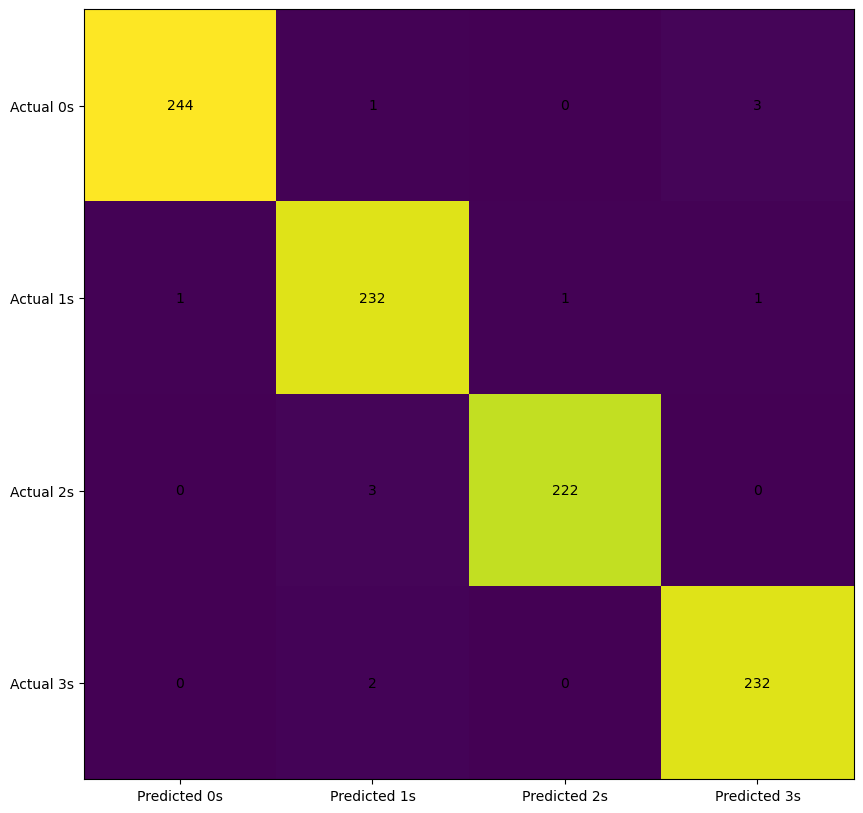

In [144]:
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TRAIN, training_data_prediction)
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(cm)
ax.xaxis.set(ticks=(0,1,2,3), ticklabels=('Predicted 0s','Predicted 1s', 'Predicted 2s','Predicted 3s'))
ax.yaxis.set(ticks=(0,1,2,3), ticklabels=('Actual 0s','Actual 1s', 'Actual 2s','Actual 3s'))
for i in range(4): 
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

In [145]:
report = classification_report(Y_TRAIN, training_data_prediction)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       248
           1       0.97      0.99      0.98       235
           2       1.00      0.99      0.99       225
           3       0.98      0.99      0.99       234

    accuracy                           0.99       942
   macro avg       0.99      0.99      0.99       942
weighted avg       0.99      0.99      0.99       942



In [146]:
# accuracy for prediction on training data
testing_data_prediction = rf_model.predict(X_TEST)
print(testing_data_prediction)

[0 3 3 2 0 1 3 1 0 2 1 2 1 2 0 0 0 2 0 0 3 2 0 2 1 2 2 1 1 2 1 1 3 2 3 1 3
 2 0 0 2 2 0 1 3 3 2 3 2 0 0 2 1 3 2 0 3 1 3 0 0 1 3 1 0 3 0 2 3 0 3 0 1 1
 1 1 2 1 2 1 2 1 2 2 1 2 1 1 3 1 2 2 0 1 0 0 2 0 3 3 3 0 2 3 0 1 0 3 0 3 2
 1 2 1 2 3 0 3 2 0 2 0 2 0 0 1 1 3 0 3 0 1 1 3 2 2 1 1 2 1 1 1 1 0 3 2 0 1
 1 3 2 1 3 3 1 3 1 3 2 1 2 1 1 1 1 3 3 2 2 0 1 0 1 3 0 3 3 3 1 1 0 1 2 3 2
 2 3 3 0 3 3 2 0 3 3 1 1 2 2 3 3 2 2 0 3 1 0 2 1 2 2 1 2 1 0 1 1 3 0 2 2 1
 3 1 0 3 3 0 3 2 1 2 0 1 2 2 3 3 0 3 1 2 1 3 0 1 0 1 1 3 1 0 3 1 2 0 2 0 0
 0 1 2 3 0 3 3 1 2 1 1 0 3 1 0 3 0 2 3 1 2 2 0 1 1 3 3 0 1 2 0 2 2 0 3 3 2
 2 1 2 3 0 3 0 3 2 1 1 3 2 3 3 2 2 1]


In [147]:
accuracy = accuracy_score(Y_TEST, testing_data_prediction)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.8535031847133758


In [148]:
confusion_matrix(Y_TEST, testing_data_prediction)

array([[59,  4,  1, 10],
       [ 1, 72,  7,  1],
       [ 0,  5, 70,  0],
       [ 9,  6,  2, 67]])

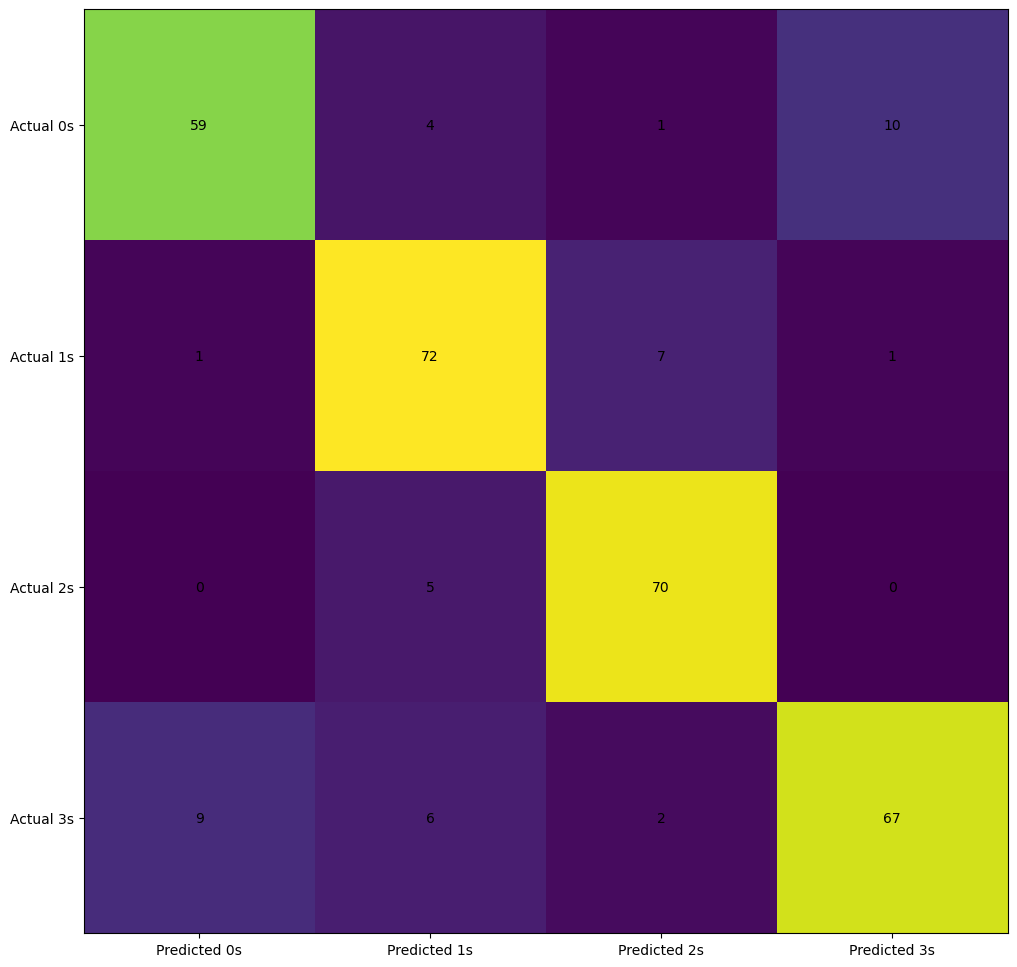

In [149]:
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TEST, testing_data_prediction)
fig, ax = plt.subplots(figsize=(12,12))
ax.imshow(cm)
ax.xaxis.set(ticks=(0,1,2,3), ticklabels=('Predicted 0s','Predicted 1s', 'Predicted 2s','Predicted 3s'))
ax.yaxis.set(ticks=(0,1,2,3), ticklabels=('Actual 0s','Actual 1s', 'Actual 2s','Actual 3s'))
for i in range(4): 
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

In [150]:
report = classification_report(Y_TEST, testing_data_prediction)
print(report)

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        74
           1       0.83      0.89      0.86        81
           2       0.88      0.93      0.90        75
           3       0.86      0.80      0.83        84

    accuracy                           0.85       314
   macro avg       0.85      0.85      0.85       314
weighted avg       0.85      0.85      0.85       314



GaussianNB Base Classifier

In [151]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

In [152]:
# fit the regressor with X and Y data 
gnb.fit(X_TRAIN, Y_TRAIN)

GaussianNB()

In [153]:
# accuracy for prediction on training data
training_data_prediction = gnb.predict(X_TRAIN)
print(training_data_prediction)

[2 1 0 3 3 2 3 3 2 2 2 2 0 0 2 2 3 2 2 1 1 2 2 0 0 2 0 2 3 2 3 2 2 3 2 2 0
 2 3 2 0 2 2 1 2 2 2 0 1 1 1 2 2 3 2 3 2 0 0 1 0 1 2 2 1 1 2 1 2 2 3 3 0 0
 3 3 1 2 2 3 3 2 2 2 2 2 3 2 2 0 3 2 1 2 1 3 3 0 0 1 2 2 3 2 2 1 2 2 3 3 0
 1 1 3 0 0 2 1 1 2 3 0 0 2 2 2 2 2 2 1 1 2 3 0 3 2 0 3 2 1 2 0 1 0 0 3 2 1
 3 3 3 3 2 2 0 3 0 2 3 0 2 3 3 2 3 2 2 3 1 2 3 2 3 0 2 3 3 0 3 1 3 0 2 0 2
 0 1 2 3 3 1 2 1 1 0 2 2 1 3 2 2 0 1 3 2 2 2 0 2 1 1 3 2 2 3 1 3 3 0 3 2 1
 3 2 3 3 2 0 3 2 2 3 1 2 3 0 3 3 1 3 0 0 3 0 2 1 1 2 0 0 2 2 3 1 2 2 3 0 1
 2 3 3 1 1 3 2 2 0 3 2 2 1 1 3 0 0 2 3 0 2 0 2 2 0 3 2 2 1 2 0 0 1 2 2 1 2
 3 1 1 0 1 0 0 0 1 1 2 0 0 3 1 2 2 2 2 2 3 3 3 0 1 1 2 3 3 3 2 0 1 2 1 3 3
 0 2 0 1 1 1 3 0 3 2 0 2 2 3 1 1 0 0 1 2 3 0 2 3 2 1 3 0 0 0 0 0 1 0 1 0 2
 2 3 1 0 1 0 1 3 0 3 1 0 1 3 1 0 1 2 0 3 2 2 1 3 0 2 0 0 0 1 3 2 2 3 0 0 3
 3 2 3 1 3 0 2 3 0 3 3 1 2 0 3 1 1 0 3 1 2 3 3 3 3 2 0 0 2 3 2 2 2 2 1 1 1
 3 0 1 0 2 1 0 2 3 3 2 0 0 3 2 2 1 3 2 3 0 3 3 0 3 0 2 0 0 2 2 3 1 2 3 3 1
 2 3 0 1 0 2 3 2 3 2 1 1 

Prediction on Train Data

In [154]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_TRAIN, training_data_prediction)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.6581740976645435


In [155]:
from sklearn.metrics import classification_report, confusion_matrix
confusion_matrix(Y_TRAIN, training_data_prediction)

array([[179,  12,   4,  53],
       [  1, 110,  82,  42],
       [  0,  11, 197,  17],
       [ 18,  50,  32, 134]])

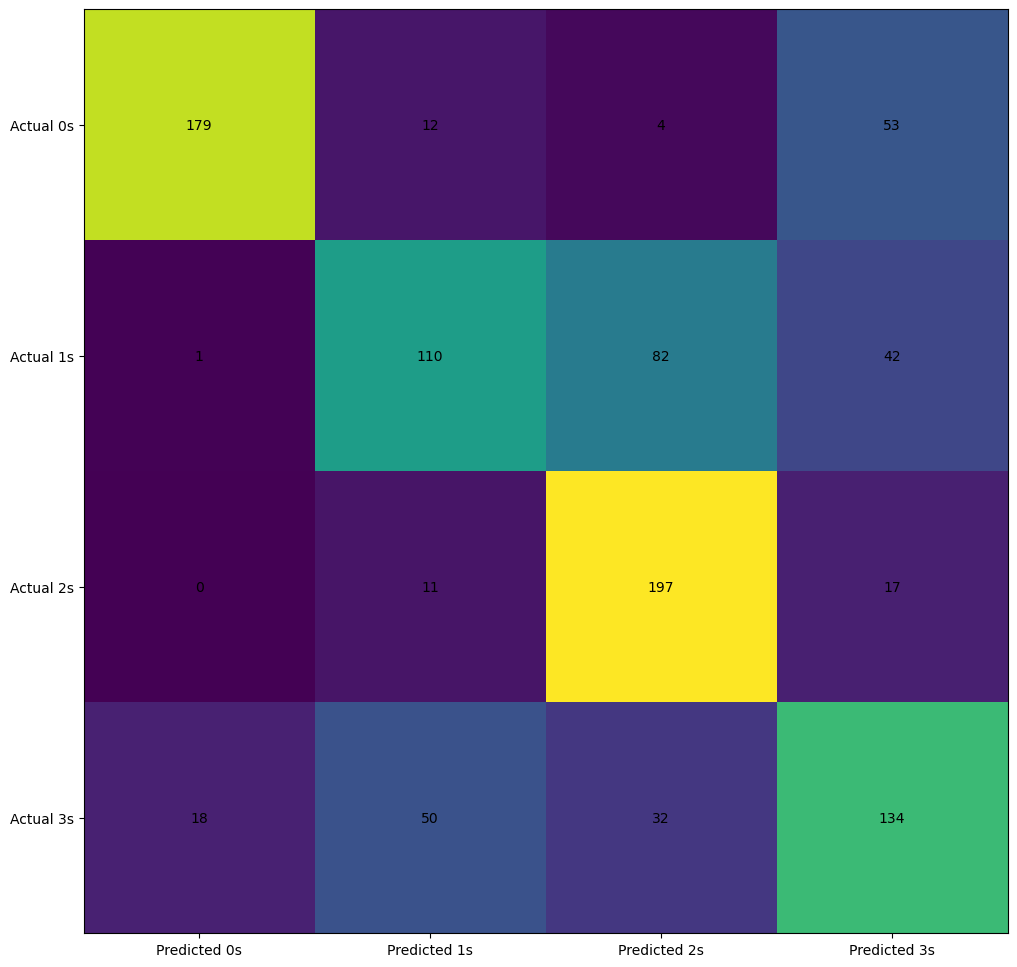

In [156]:
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TRAIN, training_data_prediction)
fig, ax = plt.subplots(figsize=(12,12))
ax.imshow(cm)
ax.xaxis.set(ticks=(0,1,2,3), ticklabels=('Predicted 0s','Predicted 1s', 'Predicted 2s','Predicted 3s'))
ax.yaxis.set(ticks=(0,1,2,3), ticklabels=('Actual 0s','Actual 1s', 'Actual 2s','Actual 3s'))
for i in range(4): 
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

In [157]:
report = classification_report(Y_TRAIN, training_data_prediction)
print(report)

              precision    recall  f1-score   support

           0       0.90      0.72      0.80       248
           1       0.60      0.47      0.53       235
           2       0.63      0.88      0.73       225
           3       0.54      0.57      0.56       234

    accuracy                           0.66       942
   macro avg       0.67      0.66      0.65       942
weighted avg       0.67      0.66      0.66       942



Testing

In [158]:
# accuracy for prediction on training data
testing_data_prediction = gnb.predict(X_TEST)
print(testing_data_prediction)

[3 0 2 2 0 1 3 1 0 2 1 2 1 2 0 0 0 2 0 3 1 2 0 2 2 2 2 1 1 2 1 1 3 2 2 1 1
 2 0 0 2 2 0 1 2 1 2 3 2 0 0 3 2 3 2 0 3 3 3 0 0 2 2 2 0 3 3 2 1 0 3 0 1 1
 1 1 3 2 2 1 2 1 2 0 2 2 2 2 3 1 2 2 3 1 0 1 3 3 1 1 2 3 2 1 3 1 3 3 0 3 2
 2 3 1 3 3 3 3 2 3 2 0 2 3 0 3 2 3 3 3 0 2 1 1 2 2 3 3 2 3 0 3 1 0 2 2 0 1
 2 3 2 3 3 3 1 1 2 3 2 1 2 2 1 1 2 3 1 2 2 0 1 0 1 3 0 0 3 3 2 3 0 2 2 3 2
 1 1 3 0 3 1 2 3 3 3 2 2 2 0 2 1 2 2 3 3 1 0 2 1 3 2 3 3 2 0 1 3 3 0 2 2 3
 3 1 0 3 3 0 3 2 2 2 0 3 2 2 3 3 0 3 0 2 2 1 3 3 0 2 1 1 1 3 2 1 2 3 2 0 0
 0 2 2 3 0 3 3 3 2 2 3 0 1 2 0 3 0 2 3 1 2 2 0 1 2 3 3 0 3 2 3 3 2 0 3 0 2
 2 2 2 3 3 3 0 3 2 1 2 3 2 3 1 2 2 2]


In [159]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_TEST, testing_data_prediction)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.6496815286624203


In [160]:
from sklearn.metrics import classification_report, confusion_matrix
confusion_matrix(Y_TEST, testing_data_prediction)

array([[50,  5,  1, 18],
       [ 2, 35, 31, 13],
       [ 0,  2, 65,  8],
       [ 4, 16, 10, 54]])

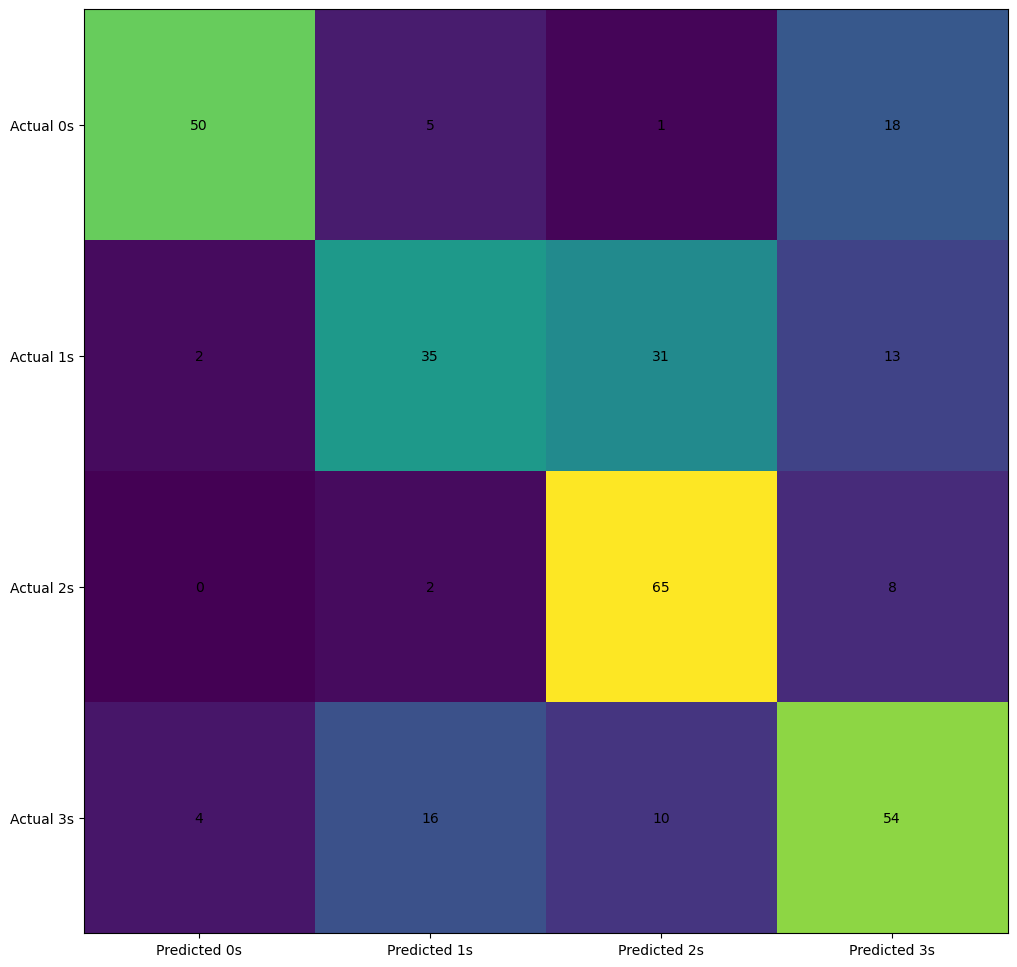

In [162]:
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TEST, testing_data_prediction)
fig, ax = plt.subplots(figsize=(12,12))
ax.imshow(cm)
ax.xaxis.set(ticks=(0,1,2,3), ticklabels=('Predicted 0s','Predicted 1s', 'Predicted 2s','Predicted 3s'))
ax.yaxis.set(ticks=(0,1,2,3), ticklabels=('Actual 0s','Actual 1s', 'Actual 2s','Actual 3s'))
for i in range(4): 
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

In [163]:
report = classification_report(Y_TEST, testing_data_prediction)
print(report)

              precision    recall  f1-score   support

           0       0.89      0.68      0.77        74
           1       0.60      0.43      0.50        81
           2       0.61      0.87      0.71        75
           3       0.58      0.64      0.61        84

    accuracy                           0.65       314
   macro avg       0.67      0.65      0.65       314
weighted avg       0.67      0.65      0.65       314



Logestic Regresssion

In [164]:
from sklearn.linear_model import LogisticRegression
ali = LogisticRegression(solver='liblinear', random_state=10)
ali.fit(X_TRAIN, Y_TRAIN)

LogisticRegression(random_state=10, solver='liblinear')

In [165]:
ali.classes_

array([0, 1, 2, 3])

In [166]:
ali.intercept_

array([ 3.10184729, -0.59714503, -5.27779356, -0.84177296])

In [167]:
ali.coef_

array([[ 1.45992646, -0.00277943, -0.60509096, -1.56312136, -0.00334178],
       [-1.17861244,  0.00300237,  0.58300401,  0.45622229, -0.00162431],
       [-0.24913791, -0.06224315, -0.09824314,  1.07156318,  0.01495423],
       [-0.05421432, -0.00162687,  0.31952272, -0.3125619 , -0.00620614]])

In [168]:
# accuracy for prediction on training data
training_data_prediction = ali.predict(X_TRAIN)
print(training_data_prediction)

[2 1 0 3 3 2 0 3 2 2 2 2 0 0 3 2 3 2 2 3 1 2 1 0 0 2 0 1 3 2 1 2 1 3 2 2 0
 2 0 1 0 2 2 1 2 2 2 0 1 3 1 1 2 0 2 3 2 0 0 1 0 1 2 2 3 2 1 1 1 2 2 3 0 0
 0 0 1 2 1 3 2 2 1 1 2 2 3 2 2 0 1 2 1 3 1 3 3 0 0 3 2 2 0 2 2 1 1 2 0 3 0
 3 1 1 0 0 2 1 1 2 3 0 0 2 3 2 2 2 2 1 3 2 3 0 0 2 0 0 1 1 2 0 1 0 0 0 2 1
 3 3 3 0 2 1 0 1 0 2 0 0 1 3 3 1 3 3 1 0 1 2 3 2 3 3 2 0 0 0 3 1 3 0 2 0 3
 0 1 2 3 3 3 2 2 1 0 1 1 1 3 2 3 0 1 1 2 2 2 0 1 3 3 0 2 2 0 1 3 0 0 0 2 1
 1 2 1 1 2 0 2 2 2 0 2 2 3 0 1 0 3 3 0 0 1 0 2 2 1 2 0 0 2 2 3 1 2 2 3 0 1
 2 3 3 2 3 2 2 2 0 0 2 2 2 1 0 0 0 2 3 0 2 0 2 2 0 0 2 2 1 2 0 0 2 2 2 3 1
 3 3 1 0 1 0 0 0 2 1 2 0 0 0 3 2 2 1 2 2 1 0 3 0 1 1 1 0 3 0 2 0 2 2 1 0 3
 0 2 0 1 3 1 3 0 1 2 0 2 3 3 1 1 0 0 2 2 3 0 2 3 2 2 3 0 0 0 0 0 2 0 1 0 1
 2 3 1 0 1 0 1 3 0 3 1 0 1 3 2 0 1 2 0 0 2 2 3 3 0 2 0 0 0 1 0 1 1 1 0 0 2
 3 2 3 3 3 0 1 3 0 2 3 1 2 0 0 3 1 0 3 1 3 3 3 3 3 2 0 0 2 0 2 2 2 3 2 3 1
 3 0 3 0 2 1 0 2 0 0 1 0 0 3 2 2 1 3 2 3 0 3 3 0 0 0 2 0 0 2 2 0 1 1 0 3 3
 2 1 0 1 0 2 3 1 2 2 2 1 

In [169]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_TRAIN, training_data_prediction)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.6411889596602972


In [170]:
from sklearn.metrics import classification_report, confusion_matrix
confusion_matrix(Y_TRAIN, training_data_prediction)

array([[204,  11,   7,  26],
       [  1, 111,  67,  56],
       [  0,  25, 183,  17],
       [ 56,  40,  32, 106]])

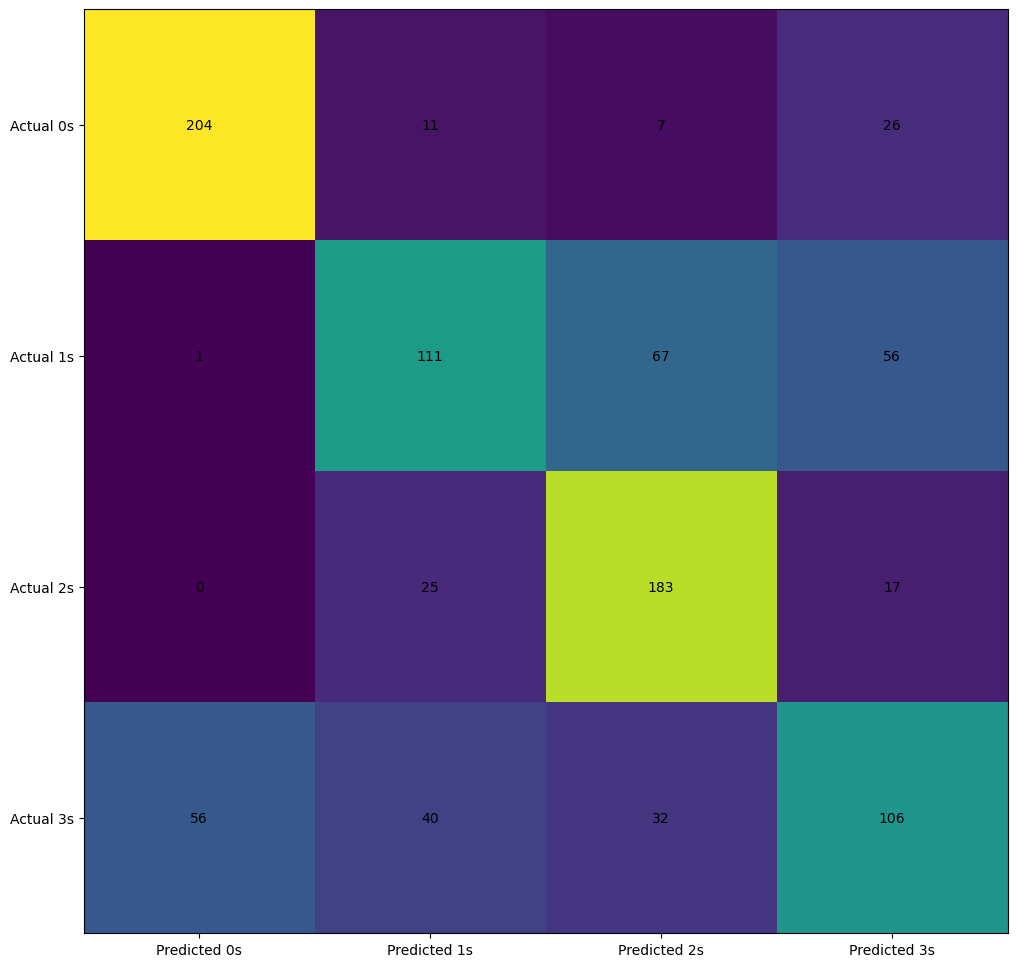

In [171]:
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TRAIN, training_data_prediction)
fig, ax = plt.subplots(figsize=(12,12))
ax.imshow(cm)
ax.xaxis.set(ticks=(0,1,2,3), ticklabels=('Predicted 0s','Predicted 1s', 'Predicted 2s','Predicted 3s'))
ax.yaxis.set(ticks=(0,1,2,3), ticklabels=('Actual 0s','Actual 1s', 'Actual 2s','Actual 3s'))
for i in range(4): 
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

In [172]:
report = classification_report(Y_TRAIN, training_data_prediction)
print(report)

              precision    recall  f1-score   support

           0       0.78      0.82      0.80       248
           1       0.59      0.47      0.53       235
           2       0.63      0.81      0.71       225
           3       0.52      0.45      0.48       234

    accuracy                           0.64       942
   macro avg       0.63      0.64      0.63       942
weighted avg       0.63      0.64      0.63       942



Testing

In [173]:
# accuracy for prediction on training data
testing_data_prediction = ali.predict(X_TEST)
print(testing_data_prediction)

[3 0 3 2 0 1 0 1 0 2 3 2 1 2 0 0 0 2 0 3 1 2 0 2 2 2 2 1 2 2 1 1 3 2 2 3 3
 2 0 0 1 2 0 1 2 1 2 2 2 0 0 3 2 3 1 0 0 2 0 0 0 2 2 2 0 3 3 2 1 0 0 0 1 3
 3 1 3 2 2 3 1 3 2 2 1 1 1 2 3 1 2 2 2 1 0 1 3 0 0 3 1 0 2 3 2 2 0 0 0 3 1
 2 2 3 2 2 0 0 2 3 2 0 2 3 0 2 2 3 0 0 0 2 2 1 2 2 3 2 2 3 3 1 1 0 2 2 0 1
 1 3 2 3 0 3 3 3 2 0 2 1 2 2 1 1 3 3 3 2 2 0 2 0 1 0 0 0 0 0 1 3 0 2 2 2 2
 1 3 0 0 3 1 2 3 0 3 1 2 1 2 3 3 2 2 0 3 1 0 2 1 0 2 3 0 3 0 1 3 3 0 2 2 3
 3 1 0 3 0 0 3 2 2 2 0 1 2 2 3 3 0 3 3 2 1 3 3 1 0 2 1 1 1 0 1 1 2 0 2 0 0
 0 1 3 3 0 0 3 3 2 2 3 0 3 3 0 3 0 1 0 2 2 2 0 1 2 2 3 0 1 2 1 3 2 0 3 0 1
 2 3 3 2 0 3 0 3 2 1 2 3 2 2 3 2 2 2]


In [174]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_TEST, testing_data_prediction)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.589171974522293


In [175]:
from sklearn.metrics import classification_report, confusion_matrix
confusion_matrix(Y_TEST, testing_data_prediction)

array([[54,  3,  4, 13],
       [ 0, 35, 24, 22],
       [ 2,  9, 60,  4],
       [25,  9, 14, 36]])

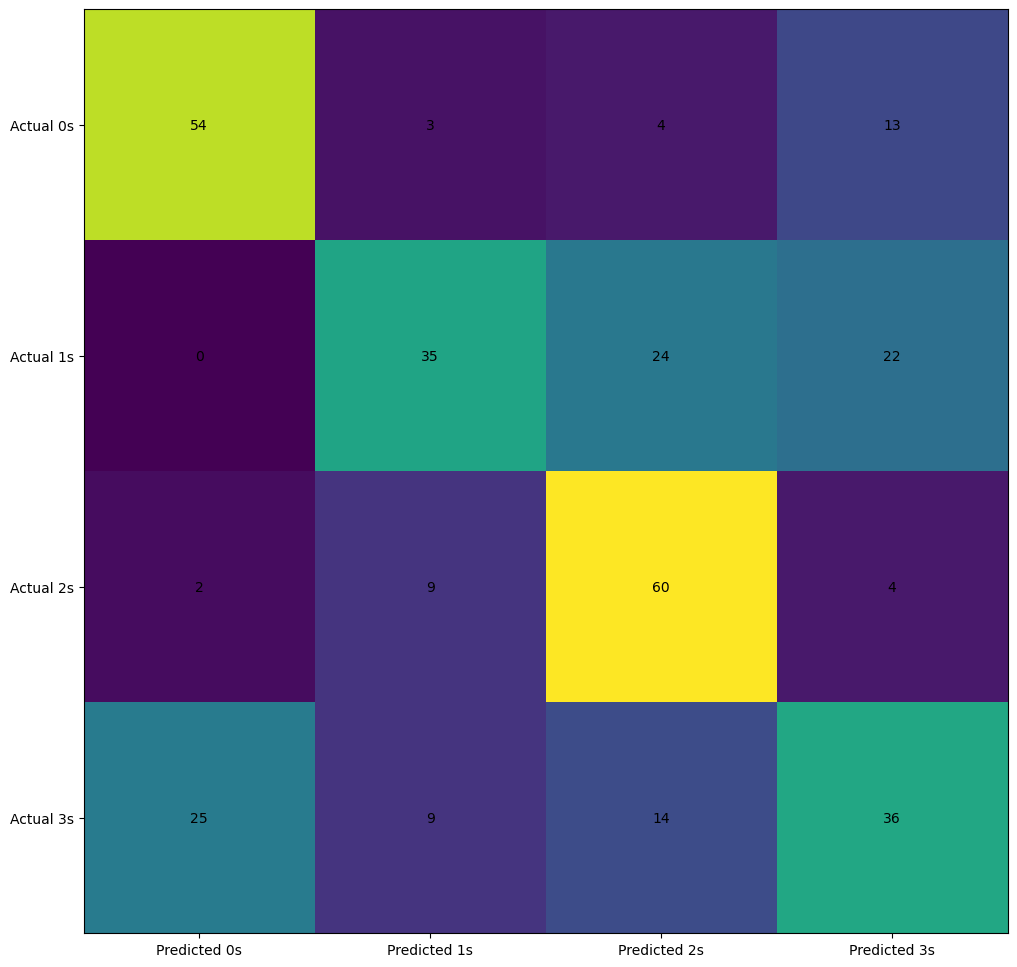

In [177]:
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TEST, testing_data_prediction)
fig, ax = plt.subplots(figsize=(12,12))
ax.imshow(cm)
ax.xaxis.set(ticks=(0,1,2,3), ticklabels=('Predicted 0s','Predicted 1s', 'Predicted 2s','Predicted 3s'))
ax.yaxis.set(ticks=(0,1,2,3), ticklabels=('Actual 0s','Actual 1s', 'Actual 2s','Actual 3s'))
for i in range(4): 
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

In [178]:
report = classification_report(Y_TEST, testing_data_prediction)
print(report)

              precision    recall  f1-score   support

           0       0.67      0.73      0.70        74
           1       0.62      0.43      0.51        81
           2       0.59      0.80      0.68        75
           3       0.48      0.43      0.45        84

    accuracy                           0.59       314
   macro avg       0.59      0.60      0.58       314
weighted avg       0.59      0.59      0.58       314



SVM CLASSIFIER

In [179]:
# #Import svm model
from sklearn import svm
# #Create a svm Classifier
ali = svm.SVC(kernel='linear') # Linear Kernel

In [180]:
X_TRAIN.shape

(942, 5)

In [181]:
# #Train the model using the training sets
ali.fit(X_TRAIN, Y_TRAIN)

SVC(kernel='linear')

In [182]:
# accuracy for prediction on training data
training_data_prediction = ali.predict(X_TRAIN)
print(training_data_prediction)

[2 1 0 3 3 2 0 3 1 2 2 2 3 0 1 2 3 1 2 3 3 2 1 0 0 2 0 1 0 2 3 2 1 3 2 2 0
 2 3 1 0 2 2 2 2 2 2 0 3 3 3 1 2 3 2 3 2 0 0 3 0 3 2 1 1 2 1 3 2 2 3 3 0 0
 0 0 1 1 1 3 3 2 1 1 2 2 3 2 2 0 1 2 1 3 1 3 3 0 0 3 1 2 3 2 2 3 1 2 0 3 0
 3 1 1 0 0 2 3 3 2 3 0 0 2 1 2 2 2 2 3 3 2 3 0 0 2 0 0 2 1 2 0 1 0 0 3 2 3
 3 3 3 3 2 1 0 1 0 2 0 0 1 1 3 1 3 1 1 3 1 3 3 2 3 3 2 0 3 0 3 3 3 0 2 0 3
 0 1 2 3 3 3 2 3 1 3 1 1 1 3 2 1 0 2 1 2 2 2 0 1 3 3 0 2 2 0 3 3 0 0 0 2 3
 3 2 3 3 1 0 2 2 2 3 3 2 3 0 3 0 3 3 0 0 3 0 2 3 1 2 0 0 2 1 3 1 2 2 3 0 3
 2 3 3 2 3 3 2 2 0 3 2 2 3 3 3 0 0 2 3 0 2 0 1 2 0 0 2 2 1 2 0 0 3 2 2 3 1
 3 3 3 0 3 0 0 0 3 1 2 0 0 0 3 2 2 1 2 2 3 3 3 0 3 3 1 0 3 0 2 0 3 2 3 0 3
 0 2 0 1 3 3 3 0 3 2 0 2 3 3 1 3 0 0 3 2 3 0 2 3 2 3 3 0 0 0 0 0 3 0 1 0 1
 2 3 1 0 3 0 1 3 0 3 1 0 1 3 2 0 1 2 0 0 2 2 3 3 0 2 0 0 0 3 3 1 1 3 0 0 3
 3 2 3 3 3 0 1 3 0 3 3 3 2 0 3 3 3 0 3 3 1 3 3 3 3 2 0 0 2 0 2 2 3 3 2 3 3
 3 0 3 0 2 3 0 2 3 3 1 0 0 3 2 2 3 3 2 3 0 3 3 0 3 0 2 0 0 2 2 3 3 1 0 3 3
 2 1 0 3 0 2 3 1 3 2 3 1 

In [183]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_TRAIN, training_data_prediction)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.6634819532908705


In [184]:
from sklearn.metrics import classification_report, confusion_matrix
confusion_matrix(Y_TRAIN, training_data_prediction)

array([[199,   3,   4,  42],
       [  0,  83,  45, 107],
       [  0,  26, 178,  21],
       [ 36,  12,  21, 165]])

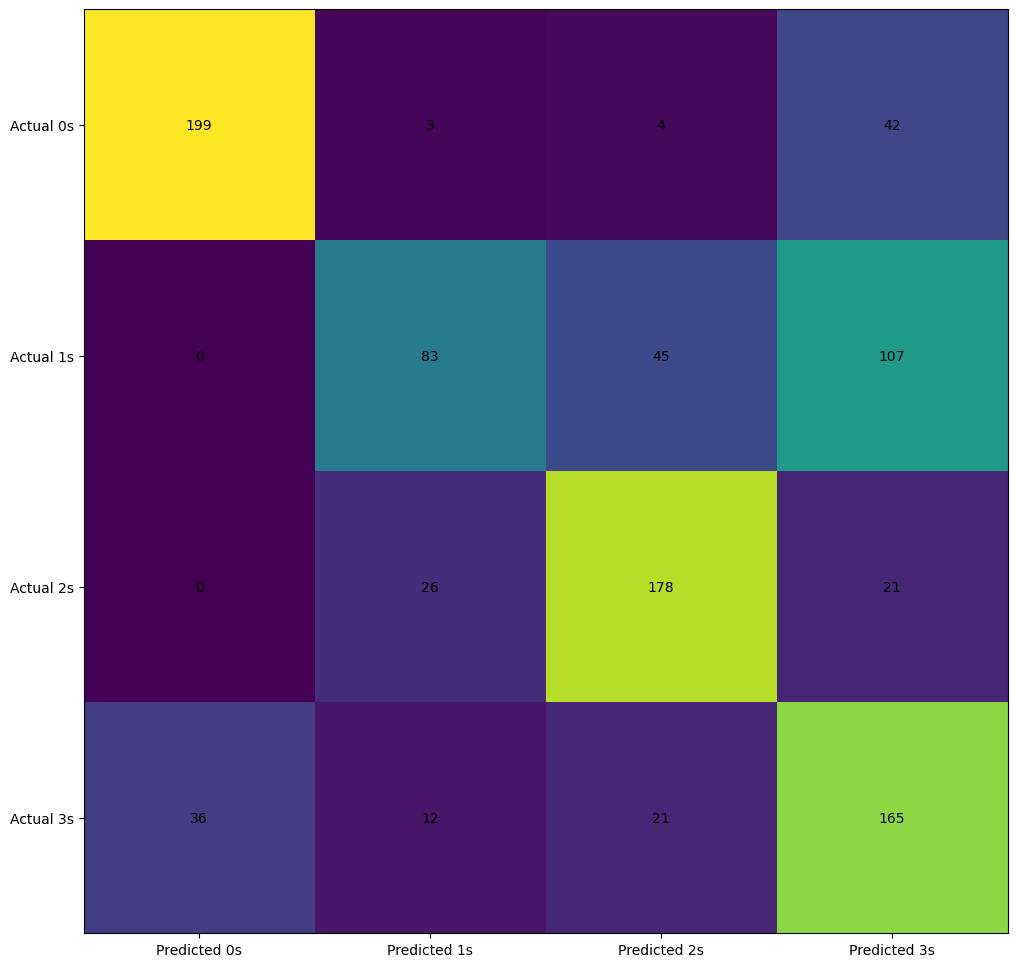

In [185]:
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TRAIN, training_data_prediction)
fig, ax = plt.subplots(figsize=(12,12))
ax.imshow(cm)
ax.xaxis.set(ticks=(0,1,2,3), ticklabels=('Predicted 0s','Predicted 1s', 'Predicted 2s','Predicted 3s'))
ax.yaxis.set(ticks=(0,1,2,3), ticklabels=('Actual 0s','Actual 1s', 'Actual 2s','Actual 3s'))
for i in range(4): 
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

In [186]:
report = classification_report(Y_TRAIN, training_data_prediction)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.80      0.82       248
           1       0.67      0.35      0.46       235
           2       0.72      0.79      0.75       225
           3       0.49      0.71      0.58       234

    accuracy                           0.66       942
   macro avg       0.68      0.66      0.65       942
weighted avg       0.68      0.66      0.66       942



Testing on Test Data

In [187]:
# accuracy for prediction on training data
testing_data_prediction = ali.predict(X_TEST)
print(testing_data_prediction)

[3 0 3 2 0 1 0 1 0 2 3 2 3 1 0 0 0 2 0 3 1 2 0 2 2 2 2 3 3 2 1 3 0 2 2 3 3
 2 0 0 1 2 0 3 2 3 2 3 1 0 0 3 2 3 1 0 3 3 3 0 0 1 2 2 0 1 3 2 3 0 1 0 3 3
 3 3 3 2 2 3 1 3 2 1 1 1 1 2 3 1 2 2 3 3 0 1 3 0 3 3 1 0 2 3 3 3 3 3 0 3 1
 2 2 3 2 3 3 0 2 3 2 0 2 3 0 2 2 3 0 3 0 2 3 3 2 2 3 3 2 3 3 3 3 0 2 2 0 2
 1 3 2 3 0 3 3 3 2 3 2 3 2 1 1 3 1 3 3 3 2 0 3 0 3 0 0 0 3 3 1 3 0 1 2 3 2
 3 3 0 0 3 3 2 0 0 3 1 2 1 1 3 3 2 2 0 3 1 0 2 1 3 2 3 3 1 0 3 3 3 0 2 2 3
 3 3 0 3 0 0 3 2 2 1 0 1 2 2 3 3 0 3 3 2 2 3 3 3 0 2 3 3 3 0 1 3 2 3 2 0 0
 0 1 1 3 0 3 3 3 2 2 3 0 3 1 0 3 0 1 0 3 2 2 0 3 2 3 3 0 1 2 3 3 2 0 3 0 1
 2 2 1 3 0 3 0 3 2 3 2 3 2 3 3 2 2 2]


In [188]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_TEST, testing_data_prediction)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.5859872611464968


In [189]:
from sklearn.metrics import classification_report, confusion_matrix
confusion_matrix(Y_TEST, testing_data_prediction)

array([[52,  1,  0, 21],
       [ 0, 22, 19, 40],
       [ 0, 11, 56,  8],
       [16,  8,  6, 54]])

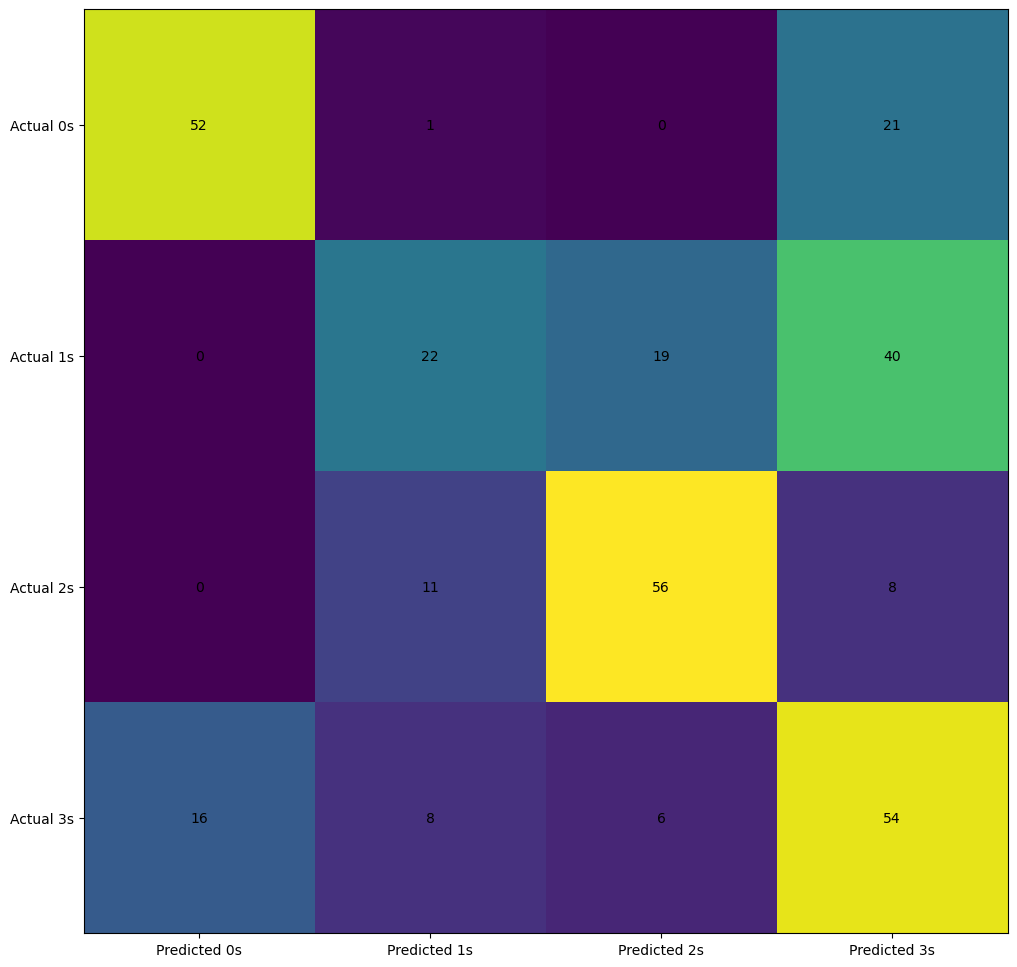

In [190]:
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TEST, testing_data_prediction)
fig, ax = plt.subplots(figsize=(12,12))
ax.imshow(cm)
ax.xaxis.set(ticks=(0,1,2,3), ticklabels=('Predicted 0s','Predicted 1s', 'Predicted 2s','Predicted 3s'))
ax.yaxis.set(ticks=(0,1,2,3), ticklabels=('Actual 0s','Actual 1s', 'Actual 2s','Actual 3s'))
for i in range(4): 
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

In [191]:
report= classification_report(Y_TEST, testing_data_prediction)
print(report)

              precision    recall  f1-score   support

           0       0.76      0.70      0.73        74
           1       0.52      0.27      0.36        81
           2       0.69      0.75      0.72        75
           3       0.44      0.64      0.52        84

    accuracy                           0.59       314
   macro avg       0.60      0.59      0.58       314
weighted avg       0.60      0.59      0.58       314



DECISION TREE CLASSIFIER

In [192]:
# from sklearn.model_selection
from sklearn.tree import DecisionTreeClassifier
# initialize decision tree classifier
dtree = DecisionTreeClassifier(random_state=30)
# train the classifier
dtree.fit(X_TRAIN, Y_TRAIN)

DecisionTreeClassifier(random_state=30)

Prediction on Train Data

In [193]:
# accuracy for prediction on training data
training_data_prediction = dtree.predict(X_TRAIN)
print(training_data_prediction)

[3 1 0 0 1 2 3 3 2 2 1 2 3 0 1 2 3 1 2 1 1 1 1 0 0 2 0 2 0 3 3 2 3 0 2 2 0
 2 3 2 0 2 2 1 2 2 2 0 1 3 1 1 1 3 1 0 2 0 0 3 0 1 3 1 0 2 1 3 2 1 3 3 0 0
 3 0 0 1 2 0 1 2 1 2 2 2 2 2 2 0 3 2 1 3 1 0 3 0 0 1 2 2 0 2 2 3 1 1 0 2 0
 1 1 1 0 0 2 3 1 2 3 0 3 2 1 2 2 2 2 3 2 2 0 0 0 3 0 0 2 1 2 3 1 0 3 3 1 3
 3 3 3 0 1 2 0 1 0 2 0 0 1 3 1 2 3 1 1 3 1 0 3 2 3 1 3 3 3 0 3 3 3 0 1 0 3
 0 1 2 3 2 0 2 1 3 0 1 1 1 3 2 1 0 1 1 2 2 2 0 3 1 3 3 3 2 3 0 1 3 0 0 1 1
 3 2 1 0 1 0 2 3 3 3 3 2 0 3 3 3 3 0 0 0 3 3 2 3 1 2 0 0 2 1 3 1 2 1 3 0 3
 2 3 3 0 3 1 2 2 0 3 2 2 1 1 0 0 0 2 2 0 1 0 2 2 0 3 2 2 3 0 0 3 3 1 2 1 1
 0 1 0 0 0 3 0 0 1 1 2 0 0 3 3 1 1 2 2 2 3 3 1 0 0 3 2 0 2 0 2 0 2 2 1 3 2
 0 2 3 1 3 1 1 0 1 1 0 2 3 3 1 3 0 0 1 2 3 0 3 3 0 3 0 0 0 0 0 0 1 0 1 0 1
 2 3 1 3 1 0 1 0 0 3 1 0 1 3 1 0 1 2 0 3 2 2 1 1 0 2 0 0 0 1 3 1 2 3 0 0 0
 1 2 2 2 3 0 1 3 0 1 3 1 2 0 3 3 1 0 3 1 1 3 0 3 2 2 0 0 2 0 2 2 3 3 2 3 3
 3 0 2 0 1 1 0 1 0 0 1 0 0 3 2 2 1 2 1 3 0 2 3 0 0 0 2 0 0 2 2 3 1 2 0 0 1
 2 3 0 1 0 2 3 1 3 2 3 1 

In [194]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_TRAIN, training_data_prediction)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  1.0


In [195]:
confusion_matrix(Y_TRAIN, training_data_prediction)

array([[248,   0,   0,   0],
       [  0, 235,   0,   0],
       [  0,   0, 225,   0],
       [  0,   0,   0, 234]])

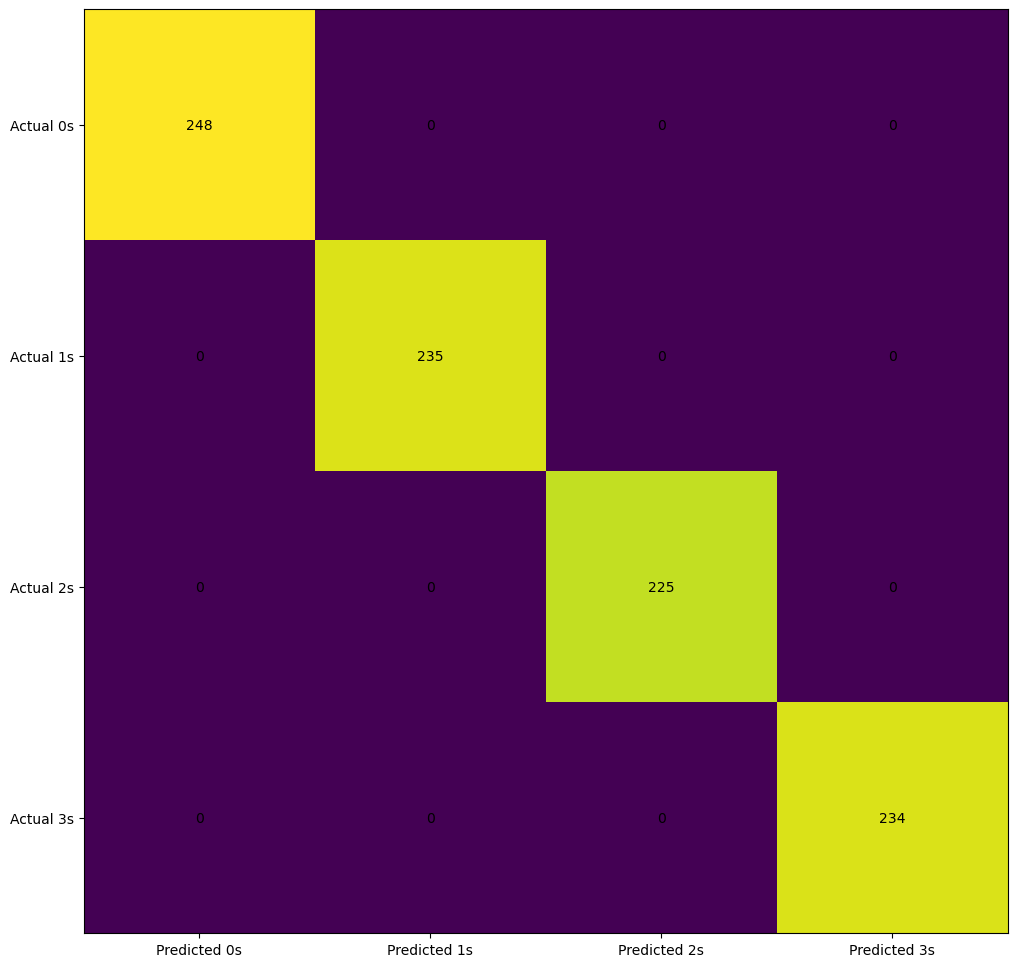

In [196]:
import matplotlib.pyplot as plt
cm = confusion_matrix(Y_TRAIN, training_data_prediction)
fig, ax = plt.subplots(figsize=(12,12))
ax.imshow(cm)
ax.xaxis.set(ticks=(0,1,2,3), ticklabels=('Predicted 0s','Predicted 1s', 'Predicted 2s','Predicted 3s'))
ax.yaxis.set(ticks=(0,1,2,3), ticklabels=('Actual 0s','Actual 1s', 'Actual 2s','Actual 3s'))
for i in range(4): 
    for j in range(4):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

In [197]:
report = classification_report(Y_TRAIN, training_data_prediction)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       248
           1       1.00      1.00      1.00       235
           2       1.00      1.00      1.00       225
           3       1.00      1.00      1.00       234

    accuracy                           1.00       942
   macro avg       1.00      1.00      1.00       942
weighted avg       1.00      1.00      1.00       942



Prediction on Test Data

In [198]:
# accuracy for prediction on training data
testing_data_prediction = dtree.predict(X_TEST)
print(testing_data_prediction)

[3 3 3 2 0 1 3 1 0 0 1 2 1 2 0 0 3 2 0 0 3 2 0 2 2 3 1 1 1 2 1 1 3 2 3 1 3
 2 0 0 2 2 0 1 3 3 2 3 2 0 0 2 1 3 2 0 3 1 1 0 0 1 3 1 0 1 0 2 3 0 3 0 1 1
 1 1 2 1 2 1 2 1 2 2 1 1 1 1 3 1 2 2 0 1 0 0 2 3 2 3 3 3 2 3 0 1 3 3 0 3 1
 2 2 1 2 3 3 3 3 3 2 0 2 3 0 3 1 3 3 3 0 1 1 3 2 2 1 1 2 1 1 1 1 0 3 2 0 1
 2 3 2 1 0 3 3 3 2 3 1 1 2 1 1 1 1 3 3 2 1 0 1 0 1 3 0 0 3 3 1 1 0 1 2 3 2
 2 3 0 0 3 3 2 0 3 1 1 1 2 2 2 3 2 2 3 3 1 0 2 1 2 2 1 2 0 0 1 1 3 0 2 2 1
 3 1 0 3 3 0 3 2 1 2 0 1 2 2 3 3 0 3 1 2 0 3 0 1 0 1 1 3 1 3 3 1 2 0 2 0 0
 0 1 1 3 0 0 3 1 2 2 0 0 3 1 0 3 0 2 3 1 2 2 0 1 1 3 3 0 1 2 0 2 2 0 3 0 2
 2 1 1 3 0 0 0 3 2 1 1 0 2 3 3 2 2 1]


In [199]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_TEST, testing_data_prediction)
print("The Accuracy of Prediction is ", accuracy)

The Accuracy of Prediction is  0.8694267515923567


In [200]:
report = classification_report(Y_TEST, testing_data_prediction)
print(report)

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        74
           1       0.87      0.94      0.90        81
           2       0.91      0.93      0.92        75
           3       0.84      0.81      0.82        84

    accuracy                           0.87       314
   macro avg       0.87      0.87      0.87       314
weighted avg       0.87      0.87      0.87       314

